<a href="https://colab.research.google.com/github/phani-x507/DeepLearning/blob/main/01_Pytorch_workfow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## PyTorch Workflow
 Lets Explore an example PyTorch end-to-end workflow


*   Data(Prepare and Load)
*   Build Model
*   Fitting the model to data (training)
*   Making predictions and evaluating the model (inference)
*   Saving and loading a model
*   Putting it all together





In [2]:
import torch
from torch import nn #Contains building blocks of neural networks
import matplotlib.pyplot as plt

#check PyTorch version
torch.__version__

'2.10.0+cpu'

# 1. Data
  - Data can be almost Anything
  - Our part is convert it into Numerical Encoding

## Lets Start with Linear Regression
 - formula `fw,b = w.x+b`


In [3]:
w = 0.7
b = 0.3

X = torch.arange(0,1,0.02).unsqueeze(dim=1) # Creates tensor and adds extra dimension 1d->2d
Y = w*X+b

X[:10] , Y[:10]


(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [4]:
X.shape,Y.shape

(torch.Size([50, 1]), torch.Size([50, 1]))

### Splitting data into training and test sets
  - One of the most important concepts in machine learning

In [5]:
# Create a train/test split
train_split = int(0.8 * len(X))
X_train, Y_train = X[:train_split] , Y[:train_split]
X_test , Y_test = X[train_split:],Y[train_split:]

len(X_train),len(Y_train),len(X_test),len(Y_test)

(40, 40, 10, 10)

In [6]:
def plot_predictions(train_data = X_train,
                     train_labels = Y_train,
                     test_data = X_test,
                     test_labels = Y_test,
                     predictions = None):
  plt.figure(figsize=(10,7))
  plt.scatter(train_data, train_labels, c='b',s=20)
  plt.scatter(test_data , test_labels , c='g',s=20)
  if predictions is not None:
    plt.scatter(test_data, predictions)
  plt.legend()
  plt.plot()

/tmp/ipykernel_7913/2480879896.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


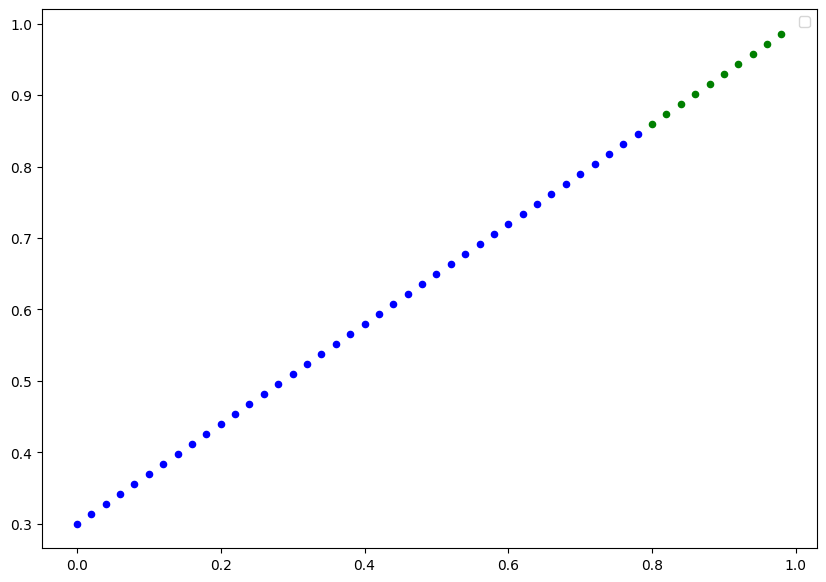

In [7]:
plot_predictions()

# Build Model
 - Build Linear Regression Model

In [8]:
from numpy import dtype
class LinearRegressionModel(nn.Module):
  def __init__(self):
    super().__init__()

    # Model takes these parameters and Learn in the background
    self.weights = nn.Parameter(torch.randn(1,
                                requires_grad=True,
                                dtype=torch.float))

    self.bias = nn.Parameter(torch.randn(1,dtype=torch.float))

  # override forward method to include computation like linear regression
  # If we subclass nn.Module, we need to override this method
  def forward(self,x:torch.Tensor) -> torch.Tensor: #->torch.Tensor: means output should be tensor
    return self.weights * x + self.bias



### Pytorch model building essentials
 - `torch.nn` -> contains the building blocks of computational graphs(a neural network can be considered as computational graph).
 - `torch.nn.Parameter` -> what parameters should our model try and learn, often a PyTorch layer from torch.nn will set these for us.
 - `torch.nn.Module` -> This is the base class for neural network modules, if you subclass it you need to override the `forward()` method.
 - `torch.optim` -> this where the PyTorch optimizers live, they will help with gradient descent.

 - See PyTorch cheatsheet for Reference.


In [9]:
# Create a random seed
torch.manual_seed(42)

# Create an instance of the model
lin_reg = LinearRegressionModel()
list(lin_reg.parameters())


[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [10]:
#List named parameters
lin_reg.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [11]:
# predicting with the method below disables all important methods like gradient Descent and other optimizations reducing the overhead.
# we don't use this regularly.
# Check in google: Pytorch inference mode twitter
with torch.inference_mode():
  y_preds = lin_reg(X_test)
y_preds

# This does the same as above but less recommended
# with torch.no_grad():
#   y_preds = lin_reg(X_test)
# y_preds
# not same but similar

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

In [13]:
#plot_predictions(predictions=y_preds)